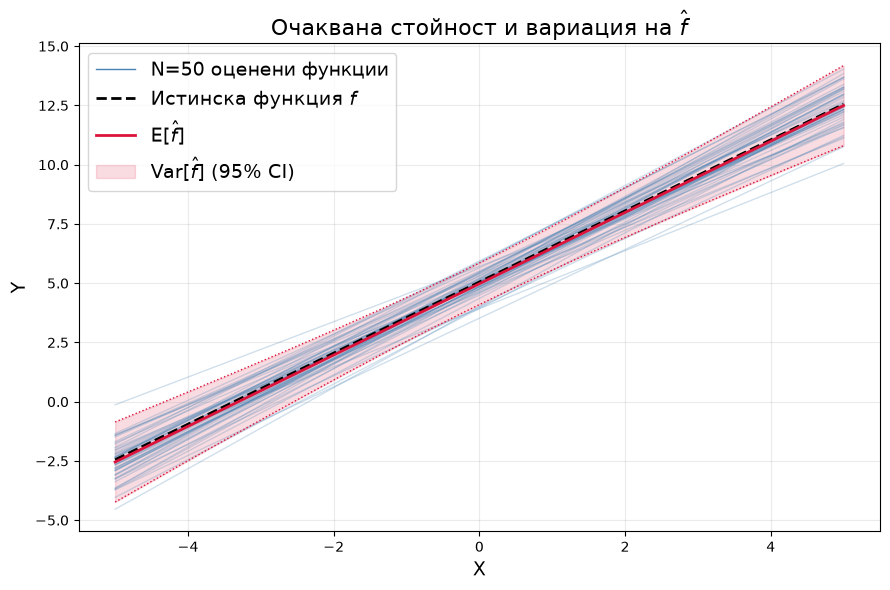

In [38]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(62)

n_samples = 50
n_points = 20

x = np.linspace(-5, 5, n_points)
true_intercept, true_slope, noise_std = 5.0, 1.5, 2.0

fitted_lines = []

for _ in range(n_samples):
    y = true_intercept + true_slope * x + rng.normal(0, noise_std, n_points)
    slope, intercept = np.polyfit(x, y, 1)
    fitted_lines.append(intercept + slope * x)

fitted_lines = np.asarray(fitted_lines)

mean_fit = fitted_lines.mean(axis=0)
true_fit = true_intercept + true_slope * x

# Теоретично стандартно отклонение за всяко x при проста линейна регресия:
# Var(f_hat(x)) = sigma^2 * (1/n_points + (x - x_bar)^2 / sum((x_i - x_bar)^2))
x_bar = np.mean(x)
ss_x = np.sum((x - x_bar)**2)
theoretical_var = (noise_std**2) * (1.0 / n_points + ((x - x_bar)**2) / ss_x)
theoretical_std = np.sqrt(theoretical_var)

# 95% теоретичен интервал за f_hat (приблизително ± 1.96 * std)
lower_bound = mean_fit - 1.96 * theoretical_std
upper_bound = mean_fit + 1.96 * theoretical_std

plt.figure(figsize=(9, 6))

for i, line in enumerate(fitted_lines):
    label = f"N={n_samples} оценени функции" if i == 0 else ""
    plt.plot(x, line, color="steelblue", alpha=0.25, linewidth=1, label=label)

plt.plot(x, true_fit+0.05, "k--", linewidth=2, label="Истинска функция $f$")
plt.plot(x, mean_fit, color="crimson", linewidth=2, alpha=1, label=r"$\text{E}[\hat{f}]$")

# Очертаване на теоретичната вариация (95% доверителен интервал)
plt.fill_between(
    x, lower_bound, upper_bound,
    color="crimson", alpha=0.15,
    label=r"$\text{Var}[\hat{f}]$ (95% CI)"
)
plt.plot(x, lower_bound, color="crimson", linestyle=":", linewidth=1)
plt.plot(x, upper_bound, color="crimson", linestyle=":", linewidth=1)

plt.xlabel("X", fontsize=14)
plt.ylabel("Y", fontsize=14)
plt.title(r"Очаквана стойност и вариация на $\hat{f}$", fontsize=16)
leg = plt.legend(loc="upper left", fontsize=14)
for handle in leg.legend_handles:
    if handle.get_label() == f"N={n_samples} оценени функции":
        handle.set_alpha(1.0)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("beamer/images/expected_value_and_theoretical_variance.png", dpi=1000)